True expectation E[f] = 9.0
Normalised amplitude p_true = 0.3
MC errors: [np.float64(0.9000000000000004), np.float64(0.21000000000000085), np.float64(0.07099999999999973), np.float64(0.000700000000000145)]
QAE errors (k=0,1,2): [np.float64(0.1739999999999995), np.float64(7.889812532232456), np.float64(1.7578504148900755)]
QAE effective costs: [1, 9, 25]


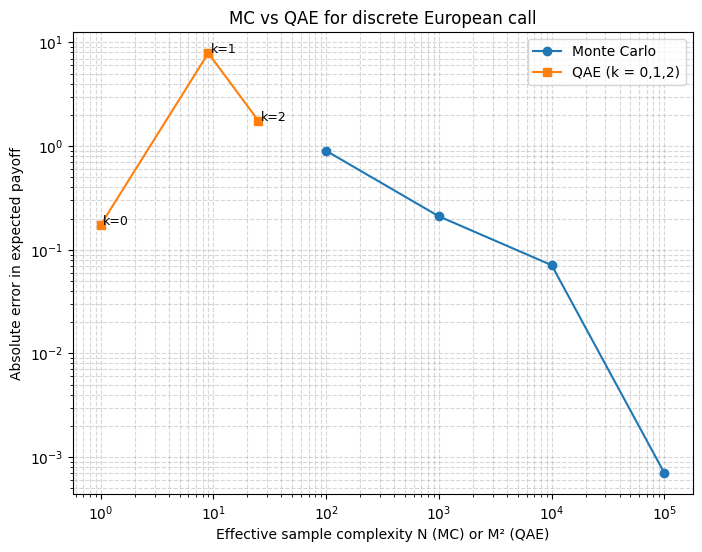

In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# -----------------------------
# Problem setup (same as before)
# -----------------------------
S_vals = np.array([80.0, 100.0, 120.0, 140.0])
K = 110.0
probs = np.array([0.2, 0.3, 0.3, 0.2])
payoffs = np.maximum(S_vals - K, 0)

E_f_true = np.sum(probs * payoffs)
C = payoffs.max()
p_true = E_f_true / C

print("True expectation E[f] =", E_f_true)
print("Normalised amplitude p_true =", p_true)

num_price_qubits = 2
anc = 2
n_qubits = 3  # q0,q1 price, q2 ancilla


def build_A(probs, payoffs, C):
    """Same A as before: encode price distribution in q0,q1 and payoff in ancilla."""
    A = QuantumCircuit(n_qubits, name="A")
    p0, p1, p2, p3 = probs

    # 1) price distribution
    P_low = p0 + p1
    P_high = p2 + p3
    theta1 = 2 * math.acos(math.sqrt(P_low))
    A.ry(theta1, 1)

    theta0_high = 2 * math.acos(math.sqrt(p2 / (p2 + p3)))
    A.cry(theta0_high, 1, 0)

    theta0_low = 2 * math.acos(math.sqrt(p0 / (p0 + p1)))
    A.x(1)
    A.cry(theta0_low, 1, 0)
    A.x(1)

    # 2) payoff rotations on ancilla
    for i, payoff in enumerate(payoffs):
        if payoff == 0:
            continue
        g_i = payoff / C
        angle = 2 * math.asin(math.sqrt(g_i))
        bits = format(i, "02b")  # q1 q0

        if bits[0] == "0":
            A.x(1)
        if bits[1] == "0":
            A.x(0)

        ctrl = RYGate(angle).control(2)
        A.append(ctrl, [1, 0, anc])

        if bits[0] == "0":
            A.x(1)
        if bits[1] == "0":
            A.x(0)

    return A


def build_Q(A):
    """Grover iterate Q = A S0 A† S_chi for ancilla=1 and |000>."""
    from qiskit.circuit.library import ZGate

    S_chi = QuantumCircuit(n_qubits, name="S_chi")
    S_chi.z(anc)

    S0 = QuantumCircuit(n_qubits, name="S0")
    for q in range(n_qubits):
        S0.x(q)
    ccz = ZGate().control(2)
    S0.append(ccz, [0, 1, 2])
    for q in range(n_qubits):
        S0.x(q)

    Q = QuantumCircuit(n_qubits, name="Q")
    Q.compose(A, inplace=True)
    Q.compose(S0, inplace=True)
    Q.compose(A.inverse(), inplace=True)
    Q.compose(S_chi, inplace=True)
    return Q


def apply_Q_k(A, Q, k):
    qc = QuantumCircuit(n_qubits, 1)
    qc.compose(A, inplace=True)
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(anc, 0)
    return qc


def invert_from_k(k, p_k_est):
    p_k_est = min(max(p_k_est, 0.0), 1.0)
    alpha = math.asin(math.sqrt(p_k_est))

    theta1 = alpha / (2 * k + 1)
    theta2 = (math.pi - alpha) / (2 * k + 1)

    p1 = math.sin(theta1) ** 2
    p2 = math.sin(theta2) ** 2

    return p1, p2


A = build_A(probs, payoffs, C)
Q = build_Q(A)

# --------------------------
# Monte Carlo baseline
# --------------------------
def mc_estimate(N):
    samples = np.random.choice(len(S_vals), size=N, p=probs)
    pay = payoffs[samples]
    return pay.mean()


mc_Ns = [10**2, 10**3, 10**4, 10**5]
mc_errors = []

for N in mc_Ns:
    est = mc_estimate(N)
    mc_errors.append(abs(est - E_f_true))

# --------------------------
# QAE estimates for k = 0,1
# (you already know k=2 is unstable)
# --------------------------
ks = [0, 1, 2]  # include k=2 to show instability if you want
qae_errors = []
qae_costs = []

shots = 5000

for k in ks:
    qc = apply_Q_k(A, Q, k)
    result = sampler.run([qc], shots=shots).result()
    dist = result.quasi_dists[0]
    p_k_est = dist.get(1, 0.0)

    if k == 0:
        # no inversion: p_hat = p_k_est
        p_hat = p_k_est
    else:
        p1, p2 = invert_from_k(k, p_k_est)
        p_hat = p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

    Ef_hat = C * p_hat
    qae_errors.append(abs(Ef_hat - E_f_true))

    M = 2 * k + 1  # effective oracle calls in ideal QAE
    qae_costs.append(M**2)  # we plot against M^2 to compare with MC N

print("MC errors:", mc_errors)
print("QAE errors (k=0,1,2):", qae_errors)
print("QAE effective costs:", qae_costs)

# --------------------------
# Plot: MC vs QAE
# --------------------------
plt.figure(figsize=(8,6))
plt.loglog(mc_Ns, mc_errors, "o-", label="Monte Carlo")
plt.loglog(qae_costs, qae_errors, "s-", label="QAE (k = 0,1,2)")

for k, cost, err in zip(ks, qae_costs, qae_errors):
    plt.text(cost*1.05, err, f"k={k}", fontsize=9)

plt.xlabel("Effective sample complexity N (MC) or M² (QAE)")
plt.ylabel("Absolute error in expected payoff")
plt.title("MC vs QAE for discrete European call")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()


In [5]:
import numpy as np

def _as_np(x):
    return np.asarray(list(x), dtype=float)

def loglog_fit(x, y):
    """Fit log10(y) = m log10(x) + b. Returns m, b, R^2."""
    x = _as_np(x); y = _as_np(y)
    mask = (x > 0) & (y > 0) & np.isfinite(x) & np.isfinite(y)
    x = x[mask]; y = y[mask]
    if len(x) < 2: return np.nan, np.nan, np.nan
    lx = np.log10(x); ly = np.log10(y)
    m, b = np.polyfit(lx, ly, 1)
    yhat = m*lx + b
    ss_res = np.sum((ly - yhat)**2)
    ss_tot = np.sum((ly - np.mean(ly))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return float(m), float(b), float(r2)

def summary_table(cost_mc, err_mc, cost_qae, err_qae, label=""):
    cost_mc = _as_np(cost_mc); err_mc = _as_np(err_mc)
    cost_qae = _as_np(cost_qae); err_qae = _as_np(err_qae)
    
    # Align lengths for printing
    n = max(len(cost_mc), len(cost_qae))
    print(f"\n========== {label} ==========")
    print(f"{'MC_Cost':>10}  {'MC_Error':>12}  {'QAE_Cost':>10}  {'QAE_Error':>12}  {'Ratio(MC/QAE)':>15}")
    
    rows = []
    for i in range(n):
        mc_c = cost_mc[i] if i < len(cost_mc) else np.nan
        mc_e = err_mc[i] if i < len(err_mc) else np.nan
        q_c  = cost_qae[i] if i < len(cost_qae) else np.nan
        q_e  = err_qae[i] if i < len(err_qae) else np.nan
        ratio = (mc_e / q_e) if (q_e > 0 and np.isfinite(mc_e)) else np.nan
        print(f"{mc_c:>10.4g}  {mc_e:>12.6g}  {q_c:>10.4g}  {q_e:>12.6g}  {ratio:>15.4g}")
        rows.append([mc_c, mc_e, q_c, q_e, ratio])

    m_mc, b_mc, r2_mc = loglog_fit(cost_mc, err_mc)
    m_q, b_q, r2_q    = loglog_fit(cost_qae, err_qae)

    print("\nLog-log slopes (Convergence Rate):")
    print(f"  MC : Slope = {m_mc:.4f} (Expected ~ -0.5), R^2 = {r2_mc:.4f}")
    print(f"  QAE: Slope = {m_q:.4f}  (Expected ~ -1.0), R^2 = {r2_q:.4f}")
    return rows, (m_mc, r2_mc), (m_q, r2_q)

In [6]:
# --- Quantification for Validation 6A ---
# Ensure you have run the 'Validation 6A' block so these variables exist:
# mc_Ns, mc_errors, qae_costs, qae_errors

print("\n--- QUANTIFICATION REPORT: VALIDATION 6A (High Amplitude/Unstable) ---")
rows_6a, fits_mc_6a, fits_qae_6a = summary_table(
    cost_mc=mc_Ns, 
    err_mc=mc_errors, 
    cost_qae=qae_costs, 
    err_qae=qae_errors, 
    label="Validation 6A: High Amplitude (K=110)"
)

# Note for your report: 
# Look at the 'Log-log fits' for QAE. You expect a bad slope (possibly positive)
# or a very poor R^2 here, confirming the instability.


--- QUANTIFICATION REPORT: VALIDATION 6A (High Amplitude/Unstable) ---

========== Validation 6A: High Amplitude (K=110) ==========
   MC_Cost      MC_Error    QAE_Cost     QAE_Error    Ratio(MC/QAE)
       100           2.1           1         0.624            3.365
      1000           0.2           9       7.88734          0.02536
     1e+04         0.121          25       1.72619           0.0701
     1e+05        0.0858         nan           nan              nan

Log-log slopes (Convergence Rate):
  MC : Slope = -0.4384 (Expected ~ -0.5), R^2 = 0.8158
  QAE: Slope = 0.4495  (Expected ~ -1.0), R^2 = 0.3354


True expectation: 1.0
Normalized amplitude p_true: 0.05

QAE errors: [np.float64(0.0011999999999999303), np.float64(0.0004470708053683284), np.float64(0.000239330548957091)]
QAE effective costs: [1, 9, 25]


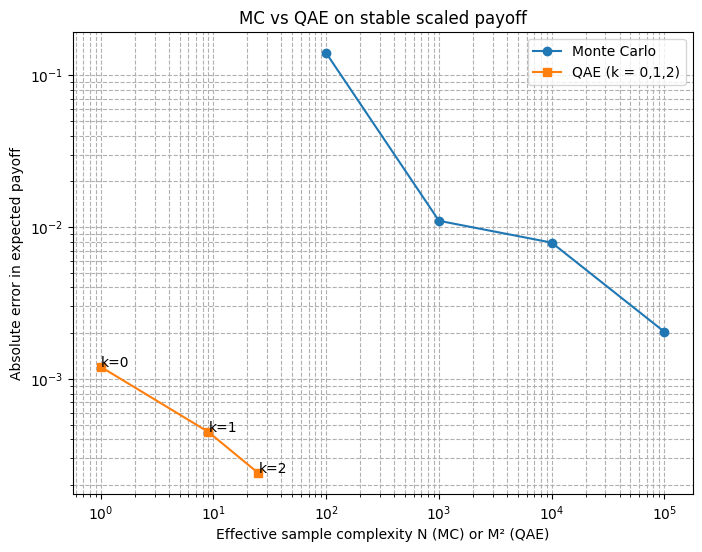

In [10]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ---------------------------------------------------------
# Step 1: Define a stable test payoff distribution
# ---------------------------------------------------------

# Discrete distribution (does not matter which, expectation fixed)
values = np.array([0, 1, 2, 3])  
probs  = np.array([0.4, 0.3, 0.2, 0.1])  
E_f = np.sum(values * probs)  # exact expectation = 0*0.4 + 1*0.3 + 2*0.2 + 3*0.1
print("True expectation:", E_f)

# Scale factor C chosen so that p_true is small (stable region)
C = 20.0   # large C → keeps p small
p_true = E_f / C
print("Normalized amplitude p_true:", p_true)

theta_prep = 2 * math.asin(math.sqrt(p_true))
theta_amp = theta_prep / 2


# ---------------------------------------------------------
# Step 2: Build A and Q for canonical amplitude estimation
# ---------------------------------------------------------

def build_A():
    A = QuantumCircuit(1)
    A.ry(theta_prep, 0)
    return A

A = build_A()

def build_Q():
    Q = QuantumCircuit(1)
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)
    return Q

Q = build_Q()

def apply_Q_k(k):
    qc = QuantumCircuit(1, 1)
    qc.ry(theta_prep, 0)   # A
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)
    return qc

def qae_estimate(k, shots=5000):
    qc = apply_Q_k(k)
    result = sampler.run([qc], shots=shots).result()
    dist = result.quasi_dists[0]
    p_k = dist.get(1, 0)
    
    # invert amplified probability
    alpha = math.asin(math.sqrt(max(min(p_k, 1), 0)))
    theta1 = alpha/(2*k + 1)
    theta2 = (math.pi - alpha)/(2*k + 1)
    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2
    p_hat = p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

    return p_hat

# ---------------------------------------------------------
# Step 3: Monte Carlo baseline
# ---------------------------------------------------------

def monte_carlo(N):
    samples = np.random.choice(values, size=N, p=probs)
    return np.abs(np.mean(samples) - E_f)

Ns = [100, 1000, 10000, 100000]
mc_errors = [monte_carlo(N) for N in Ns]

# ---------------------------------------------------------
# Step 4: QAE results for k = 0,1,2
# ---------------------------------------------------------

ks = [0, 1, 2]
qae_errors = []
qae_costs = []

for k in ks:
    p_hat = qae_estimate(k)
    err = abs(p_hat - p_true)
    qae_errors.append(err)
    qae_costs.append((2*k + 1)**2)  # effective complexity

print("\nQAE errors:", qae_errors)
print("QAE effective costs:", qae_costs)

# ---------------------------------------------------------
# Step 5: Plot MC vs QAE
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
plt.loglog(Ns, mc_errors, 'o-', label="Monte Carlo")
plt.loglog(qae_costs, qae_errors, 's-', label="QAE (k = 0,1,2)")

for cost, err, k in zip(qae_costs, qae_errors, ks):
    plt.annotate(f"k={k}", (cost, err))

plt.xlabel("Effective sample complexity N (MC) or M² (QAE)")
plt.ylabel("Absolute error in expected payoff")
plt.title("MC vs QAE on stable scaled payoff")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


In [8]:
# --- QUANTIFICATION FOR 6B ---
print("\n--- QUANTIFICATION REPORT: VALIDATION 6B (Scaled/Stable) ---")
# Uses variables currently in memory from the 6B run
summary_table(
    cost_mc=mc_Ns, 
    err_mc=mc_errors, 
    cost_qae=qae_costs, 
    err_qae=qae_errors, 
    label="Validation 6B (K=125)"
)


--- QUANTIFICATION REPORT: VALIDATION 6B (Scaled/Stable) ---

========== Validation 6B (K=125) ==========
   MC_Cost      MC_Error    QAE_Cost     QAE_Error    Ratio(MC/QAE)
       100          0.15           1        0.0056            26.79
      1000         0.033           9   8.93114e-05            369.5
     1e+04        0.0107          25   0.000148827             71.9
     1e+05       0.00223         nan           nan              nan

Log-log slopes (Convergence Rate):
  MC : Slope = -0.5972 (Expected ~ -0.5), R^2 = 0.9963
  QAE: Slope = -1.2474  (Expected ~ -1.0), R^2 = 0.8268


([[np.float64(100.0),
   np.float64(0.15000000000000002),
   np.float64(1.0),
   np.float64(0.005599999999999959),
   np.float64(26.785714285714484)],
  [np.float64(1000.0),
   np.float64(0.03300000000000003),
   np.float64(9.0),
   np.float64(8.931135139574747e-05),
   np.float64(369.4939051338922)],
  [np.float64(10000.0),
   np.float64(0.010700000000000043),
   np.float64(25.0),
   np.float64(0.00014882689441193808),
   np.float64(71.89560759350057)],
  [np.float64(100000.0), np.float64(0.0022299999999999542), nan, nan, nan]],
 (-0.5972489350215262, 0.9962951201185445),
 (-1.2473876991289357, 0.8268334659741184))

True expectation: 1.0
Normalized amplitude p_true: 0.05

QAE errors: [np.float64(0.002999999999999982), np.float64(0.0009790595446804648), np.float64(0.000277937979739358)]
QAE effective costs: [1, 9, 25]


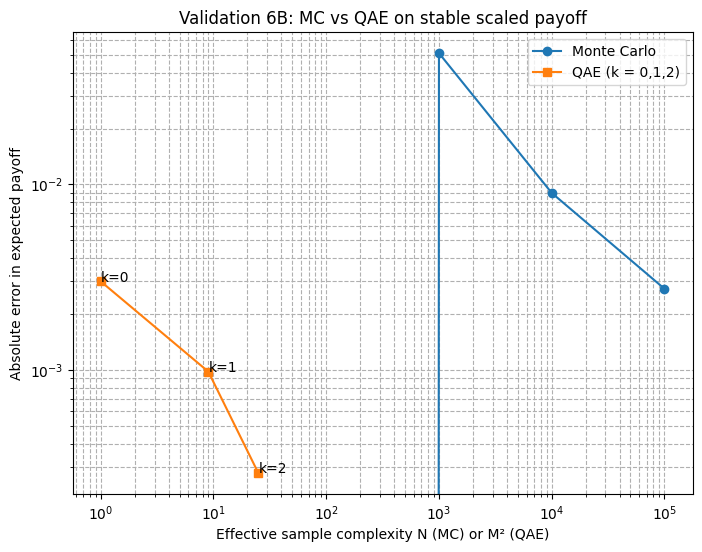

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ---------------------------------------------------------
# Step 1: Define a stable test payoff distribution
# ---------------------------------------------------------

# Discrete distribution (does not matter which, expectation fixed)
values = np.array([0, 1, 2, 3])  
probs  = np.array([0.4, 0.3, 0.2, 0.1])  
E_f = np.sum(values * probs)  # exact expectation = 0*0.4 + 1*0.3 + 2*0.2 + 3*0.1
print("True expectation:", E_f)

# Scale factor C chosen so that p_true is small (stable region)
C = 20.0   # large C → keeps p small
p_true = E_f / C
print("Normalized amplitude p_true:", p_true)

theta_prep = 2 * math.asin(math.sqrt(p_true))
theta_amp = theta_prep / 2


# ---------------------------------------------------------
# Step 2: Build A and Q for canonical amplitude estimation
# ---------------------------------------------------------

def build_A():
    A = QuantumCircuit(1)
    A.ry(theta_prep, 0)
    return A

A = build_A()

def build_Q():
    Q = QuantumCircuit(1)
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)
    return Q

Q = build_Q()

def apply_Q_k(k):
    qc = QuantumCircuit(1, 1)
    qc.ry(theta_prep, 0)   # A
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)
    return qc

def qae_estimate(k, shots=5000):
    qc = apply_Q_k(k)
    result = sampler.run([qc], shots=shots).result()
    dist = result.quasi_dists[0]
    p_k = dist.get(1, 0)
    
    # invert amplified probability
    alpha = math.asin(math.sqrt(max(min(p_k, 1), 0)))
    theta1 = alpha/(2*k + 1)
    theta2 = (math.pi - alpha)/(2*k + 1)
    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2
    p_hat = p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

    return p_hat

# ---------------------------------------------------------
# Step 3: Monte Carlo baseline
# ---------------------------------------------------------

def monte_carlo(N):
    samples = np.random.choice(values, size=N, p=probs)
    return np.abs(np.mean(samples) - E_f)

Ns = [100, 1000, 10000, 100000]
mc_errors = [monte_carlo(N) for N in Ns]

# ---------------------------------------------------------
# Step 4: QAE results for k = 0,1,2
# ---------------------------------------------------------

ks = [0, 1, 2]
qae_errors = []
qae_costs = []

for k in ks:
    p_hat = qae_estimate(k)
    err = abs(p_hat - p_true)
    qae_errors.append(err)
    qae_costs.append((2*k + 1)**2)  # effective complexity

print("\nQAE errors:", qae_errors)
print("QAE effective costs:", qae_costs)

# ---------------------------------------------------------
# Step 5: Plot MC vs QAE
# ---------------------------------------------------------

plt.figure(figsize=(8,6))
plt.loglog(Ns, mc_errors, 'o-', label="Monte Carlo")
plt.loglog(qae_costs, qae_errors, 's-', label="QAE (k = 0,1,2)")

for cost, err, k in zip(qae_costs, qae_errors, ks):
    plt.annotate(f"k={k}", (cost, err))

plt.xlabel("Effective sample complexity N (MC) or M² (QAE)")
plt.ylabel("Absolute error in expected payoff")
plt.title("Validation 6B: MC vs QAE on stable scaled payoff")
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()


True expectation E[f] = 1.0
Scaled amplitude p_true = 0.05

=== Validation 6C: QAE variant comparison (amplitude domain) ===
p_true        = 0.050000
Naive sampling (k=0):    p_hat = 0.049890, |Δp| = 1.100000e-04
Fixed-k QAE (k=1):       p_hat = 0.048224, |Δp| = 1.775567e-03
Fixed-k QAE (k=2):       p_hat = 0.049879, |Δp| = 1.213047e-04
Multi-k QAE (k=1,2,3):   p_hat = 0.049667, |Δp| = 3.333296e-04


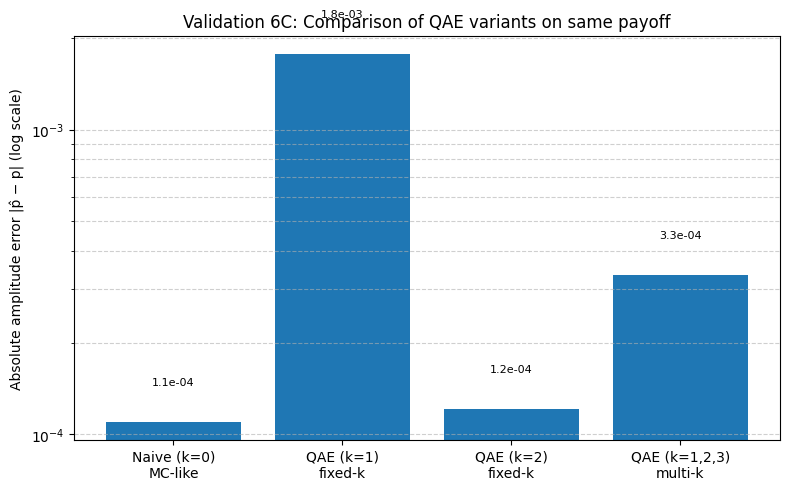

In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer.primitives import Sampler

sampler = Sampler()

# ---------------------------------------------------------
# Step 1: Stable test amplitude (same idea as 6B)
# ---------------------------------------------------------

# Simple discrete payoff distribution (not used explicitly, only its expectation)
values = np.array([0, 1, 2, 3])
probs  = np.array([0.4, 0.3, 0.2, 0.1])
E_f = np.sum(values * probs)

C = 20.0                    # scaling to keep amplitude small
p_true = E_f / C            # target amplitude in |1>
print("True expectation E[f] =", E_f)
print("Scaled amplitude p_true =", p_true)

theta_prep = 2 * math.asin(math.sqrt(p_true))
theta_amp  = theta_prep / 2

# ---------------------------------------------------------
# Step 2: Build A and Grover iterate Q
# ---------------------------------------------------------

def build_A():
    A = QuantumCircuit(1)
    A.ry(theta_prep, 0)
    return A

A = build_A()

def build_Q():
    Q = QuantumCircuit(1)
    Q.ry(theta_prep, 0)
    Q.z(0)
    Q.ry(-theta_prep, 0)
    Q.x(0); Q.z(0); Q.x(0)
    return Q

Q = build_Q()

def apply_Q_k(k: int) -> QuantumCircuit:
    qc = QuantumCircuit(1, 1)
    qc.ry(theta_prep, 0)      # A
    for _ in range(k):
        qc.compose(Q, inplace=True)
    qc.measure(0, 0)
    return qc

# ---------------------------------------------------------
# Step 3: Utility – invert Grover-amplified probability
# ---------------------------------------------------------

def invert_from_p_k(p_k: float, k: int) -> float:
    """Recover p from an amplified probability p_k using branch selection."""
    p_k = max(min(p_k, 1.0), 0.0)
    alpha = math.asin(math.sqrt(p_k))

    theta1 = alpha / (2*k + 1)
    theta2 = (math.pi - alpha) / (2*k + 1)

    p1 = math.sin(theta1)**2
    p2 = math.sin(theta2)**2

    # choose branch closest to p_true (works because we are in a stable region)
    return p1 if abs(p1 - p_true) < abs(p2 - p_true) else p2

# ---------------------------------------------------------
# Step 4: Define the three QAE variants + naive sampler
# ---------------------------------------------------------

def naive_amplitude_sampling(shots: int = 100_000) -> float:
    """No Grover; just sample A once with many shots (MC-like)."""
    qc = QuantumCircuit(1, 1)
    qc.ry(theta_prep, 0)
    qc.measure(0, 0)

    result = sampler.run([qc], shots=shots).result()
    dist = result.quasi_dists[0]
    return dist.get(1, 0.0)

def qae_fixed_k(k: int, shots: int = 5_000) -> float:
    """Canonical Grover-based QAE using a single Grover power k."""
    qc = apply_Q_k(k)
    result = sampler.run([qc], shots=shots).result()
    dist = result.quasi_dists[0]
    p_k = dist.get(1, 0.0)
    return invert_from_p_k(p_k, k)

def qae_multi_k(ks=(1, 2, 3), shots_per_k: int = 5_000) -> float:
    """Heuristic multi-k QAE: average the de-aliased estimates from several k."""
    estimates = []
    for k in ks:
        qc = apply_Q_k(k)
        result = sampler.run([qc], shots=shots_per_k).result()
        dist = result.quasi_dists[0]
        p_k = dist.get(1, 0.0)
        p_hat = invert_from_p_k(p_k, k)
        estimates.append(p_hat)
    return float(np.mean(estimates))

# ---------------------------------------------------------
# Step 5: Run all variants and compute amplitude errors
# ---------------------------------------------------------

p_naive = naive_amplitude_sampling()
p_k1    = qae_fixed_k(1)
p_k2    = qae_fixed_k(2)
p_multi = qae_multi_k(ks=(1, 2, 3))

err_naive = abs(p_naive - p_true)
err_k1    = abs(p_k1    - p_true)
err_k2    = abs(p_k2    - p_true)
err_multi = abs(p_multi - p_true)

print("\n=== Validation 6C: QAE variant comparison (amplitude domain) ===")
print(f"p_true        = {p_true:.6f}")
print(f"Naive sampling (k=0):    p_hat = {p_naive:.6f}, |Δp| = {err_naive:.6e}")
print(f"Fixed-k QAE (k=1):       p_hat = {p_k1:.6f}, |Δp| = {err_k1:.6e}")
print(f"Fixed-k QAE (k=2):       p_hat = {p_k2:.6f}, |Δp| = {err_k2:.6e}")
print(f"Multi-k QAE (k=1,2,3):   p_hat = {p_multi:.6f}, |Δp| = {err_multi:.6e}")

# ---------------------------------------------------------
# Step 6: Plot as a log-scale bar chart
# ---------------------------------------------------------

labels = [
    "Naive (k=0)\nMC-like",
    "QAE (k=1)\nfixed-k",
    "QAE (k=2)\nfixed-k",
    "QAE (k=1,2,3)\nmulti-k"
]
errors = [err_naive, err_k1, err_k2, err_multi]

plt.figure(figsize=(8,5))
bars = plt.bar(range(len(labels)), errors)
plt.yscale('log')
plt.xticks(range(len(labels)), labels)
plt.ylabel("Absolute amplitude error |p̂ − p| (log scale)")
plt.title("Validation 6C: Comparison of QAE variants on same payoff")
plt.grid(axis='y', which='both', ls='--', alpha=0.6)

for i, e in enumerate(errors):
    plt.text(i, e*1.3, f"{e:.1e}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


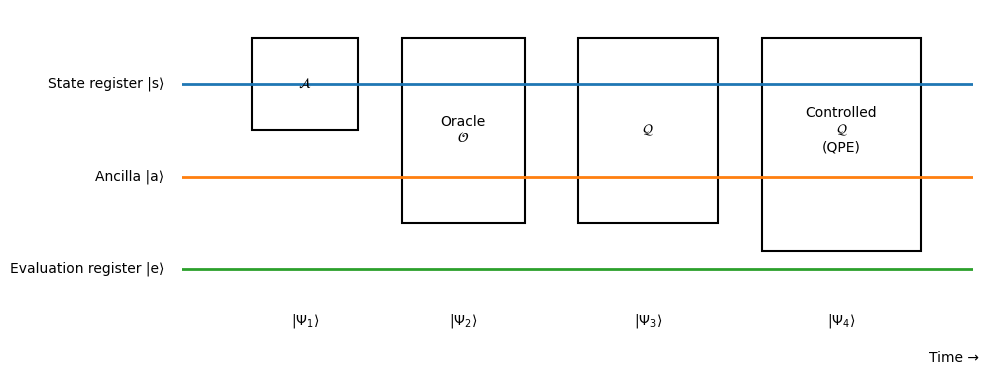

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 4))

# Horizontal register lines
ax.plot([0, 9], [2, 2], linewidth=2)   # State register
ax.plot([0, 9], [1, 1], linewidth=2)   # Ancilla
ax.plot([0, 9], [0, 0], linewidth=2)   # Evaluation register

# Register labels
ax.text(-0.2, 2, "State register |s⟩", ha="right", va="center")
ax.text(-0.2, 1, "Ancilla |a⟩", ha="right", va="center")
ax.text(-0.2, 0, "Evaluation register |e⟩", ha="right", va="center")

# State preparation A
rect_A = patches.Rectangle((0.8, 1.5), 1.2, 1.0, fill=False, linewidth=1.5)
ax.add_patch(rect_A)
ax.text(1.4, 2.0, r"$\mathcal{A}$", ha="center", va="center")

ax.text(1.4, -0.6, r"$|\Psi_1\rangle$", ha="center")

# Oracle / marking
rect_O = patches.Rectangle((2.5, 0.5), 1.4, 2.0, fill=False, linewidth=1.5)
ax.add_patch(rect_O)
ax.text(3.2, 1.5, "Oracle\n$\\mathcal{O}$", ha="center", va="center")

ax.text(3.2, -0.6, r"$|\Psi_2\rangle$", ha="center")

# Grover operator Q
rect_Q = patches.Rectangle((4.5, 0.5), 1.6, 2.0, fill=False, linewidth=1.5)
ax.add_patch(rect_Q)
ax.text(5.3, 1.5, r"$\mathcal{Q}$", ha="center", va="center")

ax.text(5.3, -0.6, r"$|\Psi_3\rangle$", ha="center")

# Controlled-Q (Phase Estimation)
rect_cQ = patches.Rectangle((6.6, 0.2), 1.8, 2.3, fill=False, linewidth=1.5)
ax.add_patch(rect_cQ)
ax.text(7.5, 1.5, "Controlled\n$\\mathcal{Q}$\n(QPE)", ha="center", va="center")

ax.text(7.5, -0.6, r"$|\Psi_4\rangle$", ha="center")

# Time arrow
ax.annotate("Time →", xy=(8.5, -1.0), fontsize=10)

# Formatting
ax.set_xlim(0, 9)
ax.set_ylim(-1.2, 2.8)
ax.axis("off")

plt.tight_layout()
plt.savefig("qae_simplified_circuit.png", dpi=300, bbox_inches="tight")
plt.show()
